# Assignment 2 - Task 2
Run Cell 2 once for setup, then run one model cell at a time (Cells 3 to 8), one plot per cell.

In [ ]:
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


@dataclass(frozen=True)
class SeasonalModelSpec:
    name: str
    p: int
    d: int
    q: int
    P: int
    D: int
    Q: int
    s: int
    phi: Dict[int, float]
    theta: Dict[int, float]
    Phi: Dict[int, float]
    Theta: Dict[int, float]
    comments: list[str]


def _poly_dict_from_terms(terms: Dict[int, float] | None = None) -> Dict[int, float]:
    poly = {0: 1.0}
    if terms:
        for lag, coef in terms.items():
            poly[int(lag)] = float(coef)
    return poly


def _poly_multiply(poly_a: Dict[int, float], poly_b: Dict[int, float]) -> Dict[int, float]:
    out: Dict[int, float] = {}
    for lag_a, coef_a in poly_a.items():
        for lag_b, coef_b in poly_b.items():
            lag = lag_a + lag_b
            out[lag] = out.get(lag, 0.0) + coef_a * coef_b
    return out


def _seasonal_terms(terms: Dict[int, float], s: int) -> Dict[int, float]:
    return {k * s: v for k, v in terms.items()}


def _simulate_arma_plus(
    ar_poly: Dict[int, float],
    ma_poly: Dict[int, float],
    n: int,
    burnin: int,
    sigma: float,
    rng: np.random.Generator,
) -> np.ndarray:
    total_n = n + burnin
    max_ar_lag = max(ar_poly) if ar_poly else 0
    max_ma_lag = max(ma_poly) if ma_poly else 0

    e = rng.normal(loc=0.0, scale=sigma, size=total_n + max_ma_lag + 1)
    y = np.zeros(total_n + max_ar_lag + 1, dtype=float)

    for t in range(total_n):
        ma_part = e[t + max_ma_lag]
        for lag, coef in ma_poly.items():
            if lag == 0:
                continue
            ma_part += coef * e[t + max_ma_lag - lag]

        ar_part = 0.0
        for lag, coef in ar_poly.items():
            if lag == 0:
                continue
            ar_part += coef * y[t + max_ar_lag - lag]

        y[t + max_ar_lag] = ma_part - ar_part

    return y[max_ar_lag + burnin : max_ar_lag + burnin + n]


def simulate_multiplicative_sarima(
    spec: SeasonalModelSpec,
    n: int = 360,
    burnin: int = 600,
    sigma: float = 1.0,
    seed: int = 7,
) -> np.ndarray:
    if spec.d != 0 or spec.D != 0:
        raise ValueError("This notebook simulates only models with d=0 and D=0.")

    ar_nonseasonal = _poly_dict_from_terms(spec.phi)
    ma_nonseasonal = _poly_dict_from_terms(spec.theta)
    ar_seasonal = _poly_dict_from_terms(_seasonal_terms(spec.Phi, spec.s))
    ma_seasonal = _poly_dict_from_terms(_seasonal_terms(spec.Theta, spec.s))

    ar_poly = _poly_multiply(ar_nonseasonal, ar_seasonal)
    ma_poly = _poly_multiply(ma_nonseasonal, ma_seasonal)

    rng = np.random.default_rng(seed)
    return _simulate_arma_plus(ar_poly, ma_poly, n=n, burnin=burnin, sigma=sigma, rng=rng)


def plot_model_results(
    series: np.ndarray,
    spec: SeasonalModelSpec,
    out_dir: Path,
    n_lags: int = 60,
) -> Path:
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)

    axes[0].plot(series, color="#1f77b4", linewidth=1.0)
    axes[0].set_title("Simulated series", fontsize=16, fontweight="bold")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Y")

    plot_acf(series, lags=n_lags, ax=axes[1])
    axes[1].set_title("ACF", fontsize=16, fontweight="bold")
    axes[1].set_xlabel("Lag")
    axes[1].set_ylabel("Correlation")

    plot_pacf(series, lags=n_lags, method="ywm", ax=axes[2])
    axes[2].set_title("PACF", fontsize=16, fontweight="bold")
    axes[2].set_xlabel("Lag")
    axes[2].set_ylabel("Partial correlation")

    safe_name = spec.name.split(":")[0].replace(" ", "_").replace(".", "")
    out_path = out_dir / f"{safe_name}.png"
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    return out_path


def build_task_2_specs() -> Iterable[SeasonalModelSpec]:
    s = 12
    return [
        SeasonalModelSpec(
            name="2.1: (1,0,0)x(0,0,0)12 with phi1=0.6",
            p=1, d=0, q=0, P=0, D=0, Q=0, s=s,
            phi={1: 0.6}, theta={}, Phi={}, Theta={},
            comments=[
                "AR(1)-type persistence: smooth series with gradual mean reversion.",
                "ACF decays geometrically; PACF shows strongest effect at lag 1.",
            ],
        ),
        SeasonalModelSpec(
            name="2.2: (0,0,0)x(1,0,0)12 with Phi1=-0.9",
            p=0, d=0, q=0, P=1, D=0, Q=0, s=s,
            phi={}, theta={}, Phi={1: -0.9}, Theta={},
            comments=[
                "Strong seasonal AR at lag 12: dependence repeats every year.",
                "ACF/PACF highlight seasonal spikes at lags 12, 24, 36, ... .",
            ],
        ),
        SeasonalModelSpec(
            name="2.3: (1,0,0)x(0,0,1)12 with phi1=0.9, Theta1=-0.7",
            p=1, d=0, q=0, P=0, D=0, Q=1, s=s,
            phi={1: 0.9}, theta={}, Phi={}, Theta={1: -0.7},
            comments=[
                "Very persistent short-run AR behavior plus seasonal MA shock pattern.",
                "ACF tends to stay high at low lags and shows seasonal modulation.",
            ],
        ),
        SeasonalModelSpec(
            name="2.4: (1,0,0)x(1,0,0)12 with phi1=-0.6, Phi1=-0.8",
            p=1, d=0, q=0, P=1, D=0, Q=0, s=s,
            phi={1: -0.6}, theta={}, Phi={1: -0.8}, Theta={},
            comments=[
                "Both non-seasonal and seasonal AR terms generate structured dependence.",
                "PACF often has strong spikes at lag 1 and seasonal multiples.",
            ],
        ),
        SeasonalModelSpec(
            name="2.5: (0,0,1)x(0,0,1)12 with theta1=0.4, Theta1=-0.8",
            p=0, d=0, q=1, P=0, D=0, Q=1, s=s,
            phi={}, theta={1: 0.4}, Phi={}, Theta={1: -0.8},
            comments=[
                "MA effects are shock-driven and finite-memory in both regular and seasonal lags.",
                "ACF shows short-run and seasonal signatures; PACF decays more gradually.",
            ],
        ),
        SeasonalModelSpec(
            name="2.6: (0,0,1)x(1,0,0)12 with theta1=-0.4, Phi1=0.7",
            p=0, d=0, q=1, P=1, D=0, Q=0, s=s,
            phi={}, theta={1: -0.4}, Phi={1: 0.7}, Theta={},
            comments=[
                "Seasonal AR persistence combines with one-step MA shock correction.",
                "Seasonal pattern appears strongly at lag 12 and multiples in ACF/PACF.",
            ],
        ),
    ]


def print_summary_27() -> None:
    print("2.7 Summary observations")
    print("- Seasonal models produce repeated ACF/PACF structure at lags s, 2s, 3s, ... .")
    print("- Seasonal AR terms often create persistent seasonal correlations (slow decay at seasonal lags).")
    print("- Seasonal MA terms produce more localized seasonal spikes that damp out faster.")
    print("- Adding non-seasonal AR/MA changes short-lag behavior while seasonal signatures remain visible.")


def run_model(model_number: int, n: int = 360, burnin: int = 600, sigma: float = 1.0) -> Path:
    if (Path.cwd() / "Task2.py").exists():
        base_dir = Path.cwd()
    elif (Path.cwd() / "Assignment2" / "Task2.py").exists():
        base_dir = Path.cwd() / "Assignment2"
    else:
        base_dir = Path.cwd()

    out_dir = base_dir / "task2_outputs"
    out_dir.mkdir(parents=True, exist_ok=True)

    specs = list(build_task_2_specs())
    if model_number < 1 or model_number > len(specs):
        raise ValueError(f"model_number must be between 1 and {len(specs)}")

    spec = specs[model_number - 1]
    series = simulate_multiplicative_sarima(spec, n=n, burnin=burnin, sigma=sigma, seed=100 + model_number)
    fig_path = plot_model_results(series, spec, out_dir=out_dir, n_lags=60)

    print(spec.name)
    print(f"- Figure: {fig_path}")
    for line in spec.comments:
        print(f"- {line}")

    display(Image(filename=str(fig_path)))
    return fig_path


print("Setup complete. Run Cells 3 to 8 for models 2.1 to 2.6.")
print("Run Cell 9 for the 2.7 summary text.")

Setup complete. Run Cells 3 to 8 for models 2.1 to 2.6.
Run Cell 9 for the 2.7 summary text.


2.1: (1,0,0)x(0,0,0)12 with phi1=0.6
- Figure: c:\Users\cheli\OneDrive\Dokumenter\GitHub\TimeSeriesAnalysis_Assignments\Assignment2\task2_outputs\21.png
- AR(1)-type persistence: smooth series with gradual mean reversion.
- ACF decays geometrically; PACF shows strongest effect at lag 1.


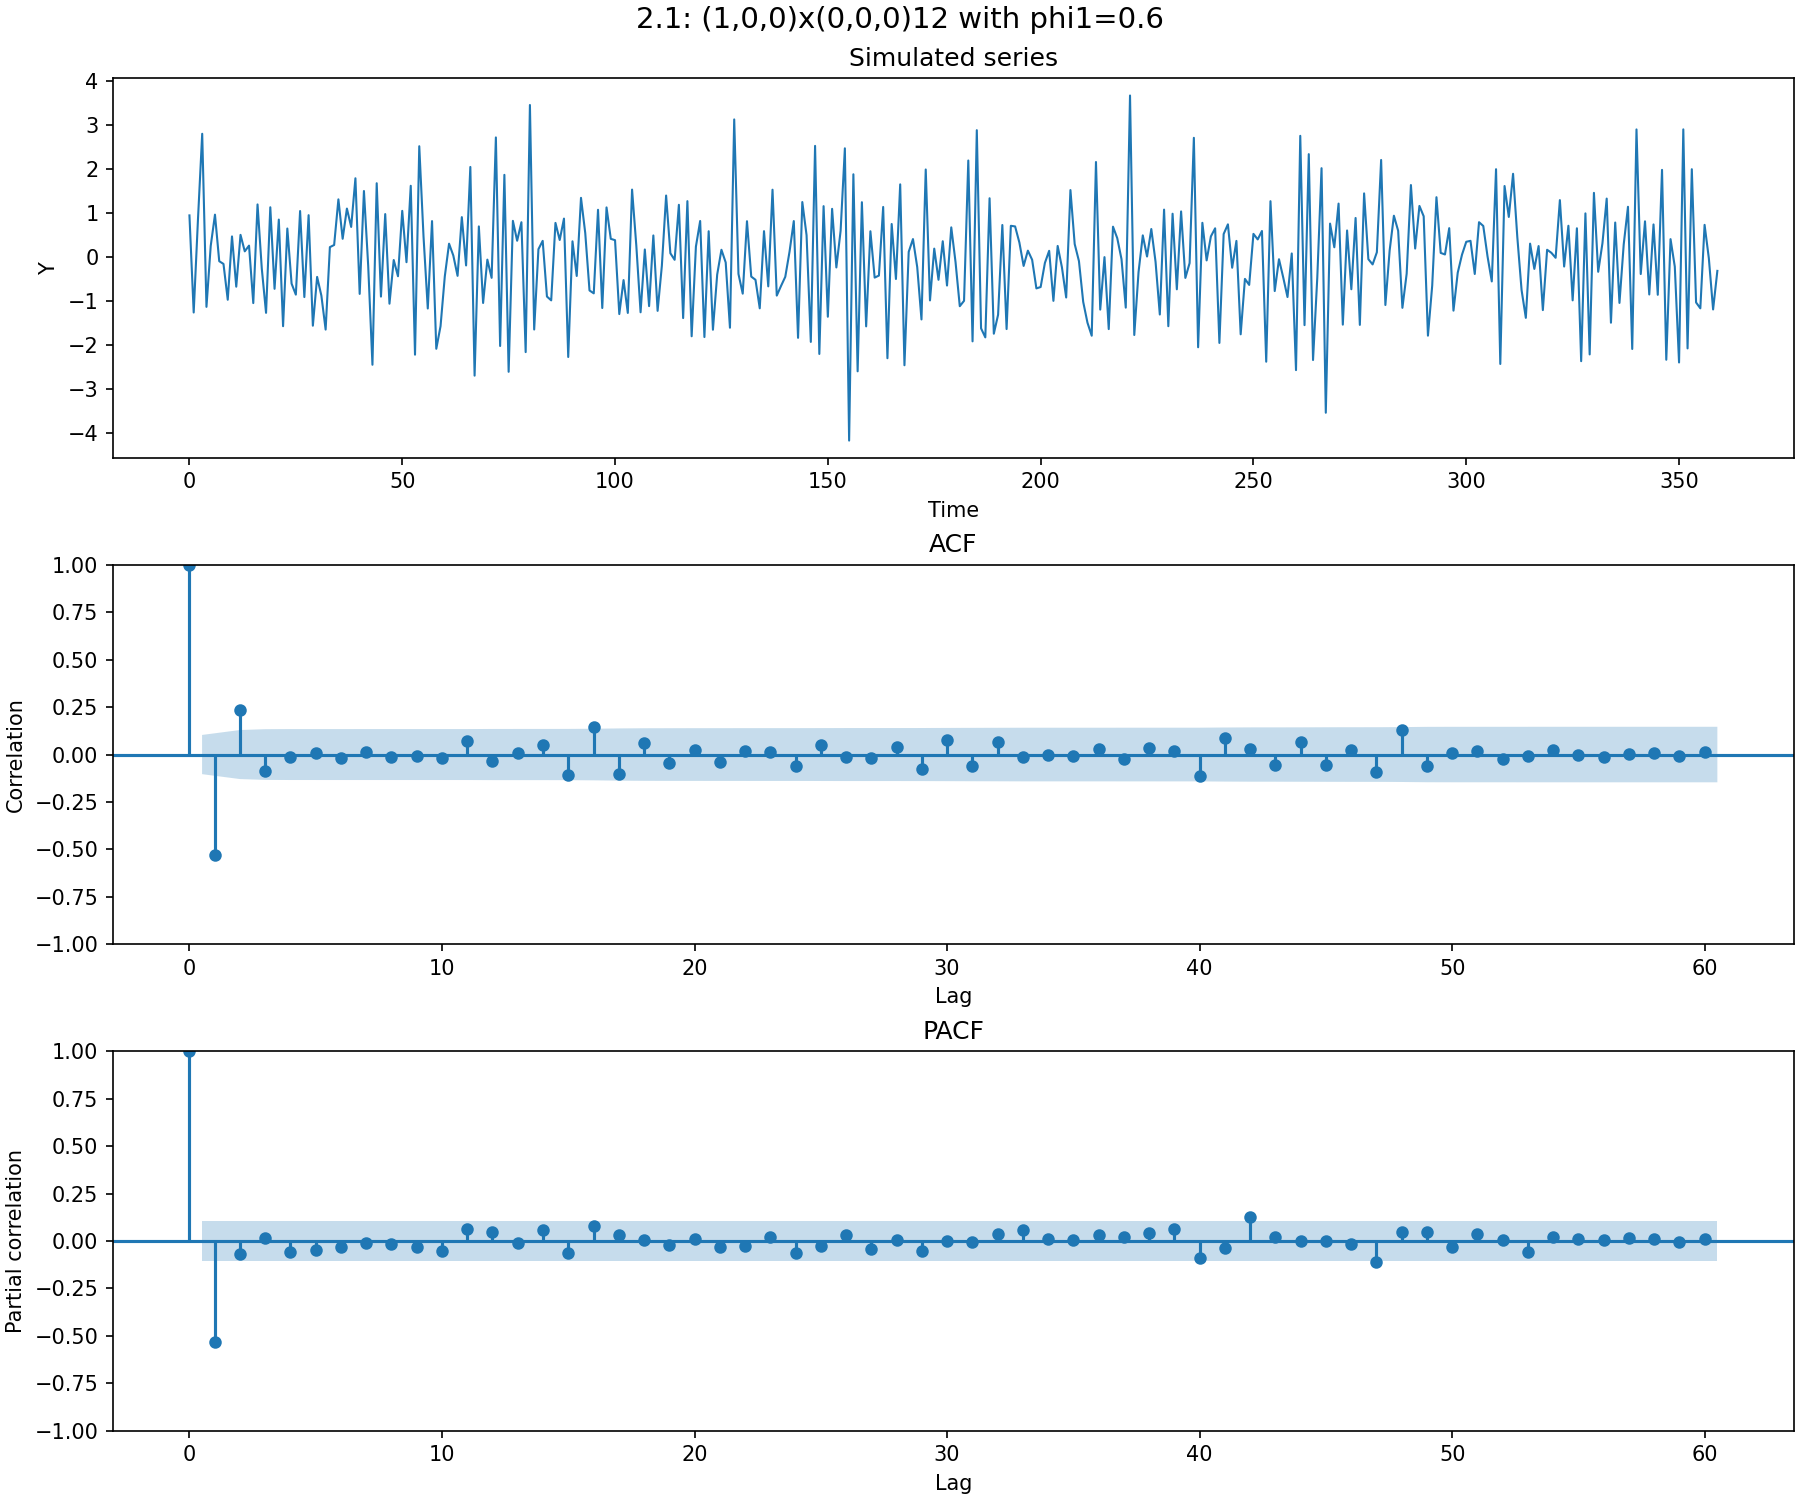

WindowsPath('c:/Users/cheli/OneDrive/Dokumenter/GitHub/TimeSeriesAnalysis_Assignments/Assignment2/task2_outputs/21.png')

In [20]:
# 2.1
run_model(1)

Short comment: This behaves like a standard AR(1): the series shows smooth persistence, the ACF decays gradually, and the PACF is mainly strong at lag 1.

2.2: (0,0,0)x(1,0,0)12 with Phi1=-0.9
- Figure: c:\Users\cheli\OneDrive\Dokumenter\GitHub\TimeSeriesAnalysis_Assignments\Assignment2\task2_outputs\22.png
- Strong seasonal AR at lag 12: dependence repeats every year.
- ACF/PACF highlight seasonal spikes at lags 12, 24, 36, ... .


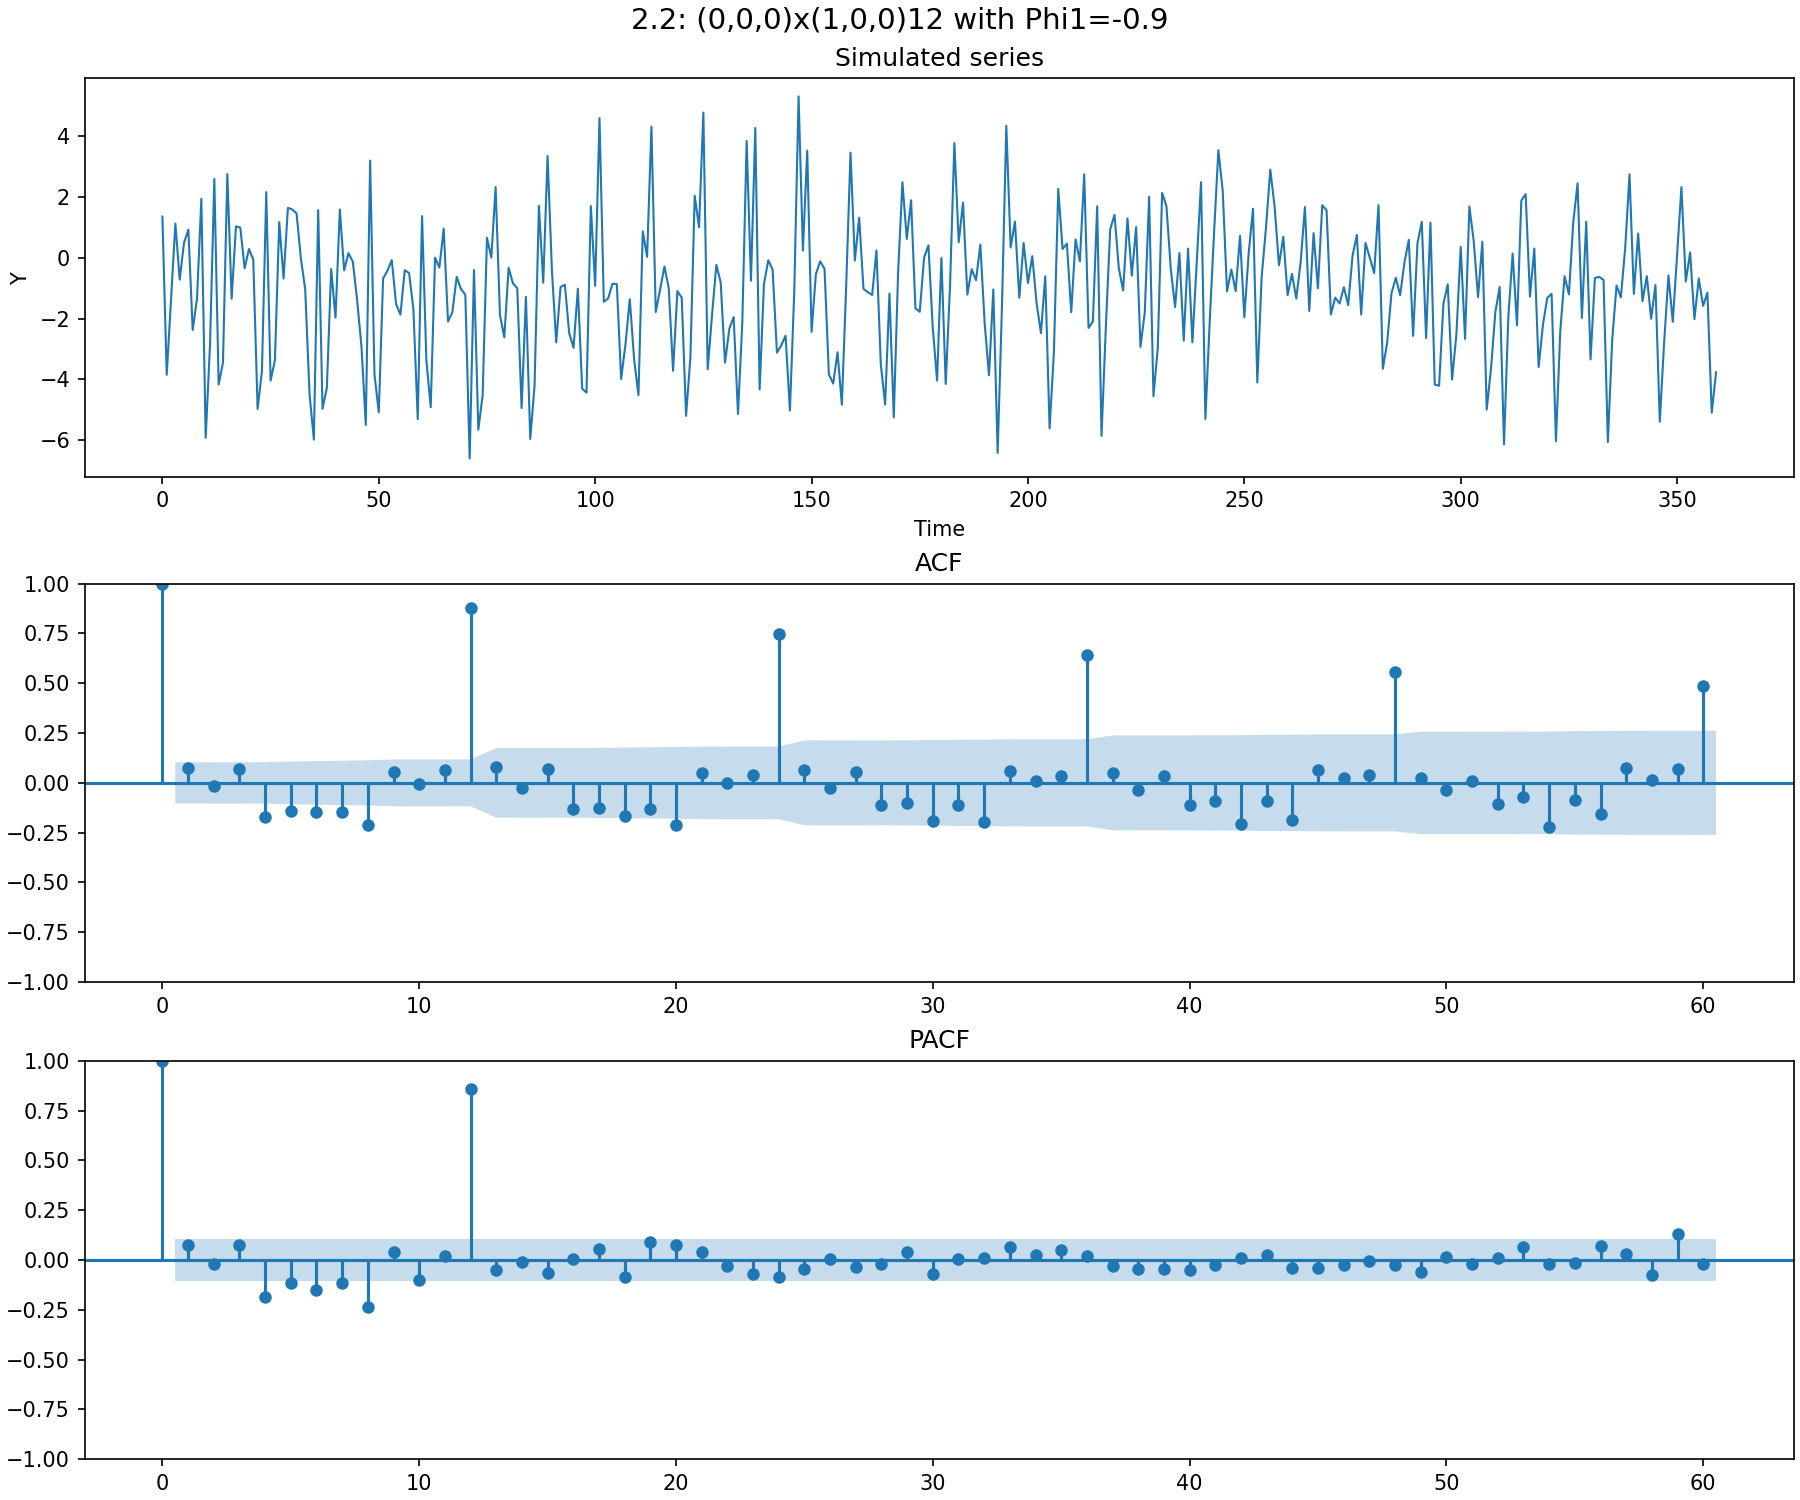

WindowsPath('c:/Users/cheli/OneDrive/Dokumenter/GitHub/TimeSeriesAnalysis_Assignments/Assignment2/task2_outputs/22.png')

In [13]:
# 2.2
run_model(2)

Short comment: Clear seasonal AR behavior is visible, with pronounced dependence at lags 12, 24, 36, ... in ACF/PACF.

2.3: (1,0,0)x(0,0,1)12 with phi1=0.9, Theta1=-0.7
- Figure: c:\Users\cheli\OneDrive\Dokumenter\GitHub\TimeSeriesAnalysis_Assignments\Assignment2\task2_outputs\23.png
- Very persistent short-run AR behavior plus seasonal MA shock pattern.
- ACF tends to stay high at low lags and shows seasonal modulation.


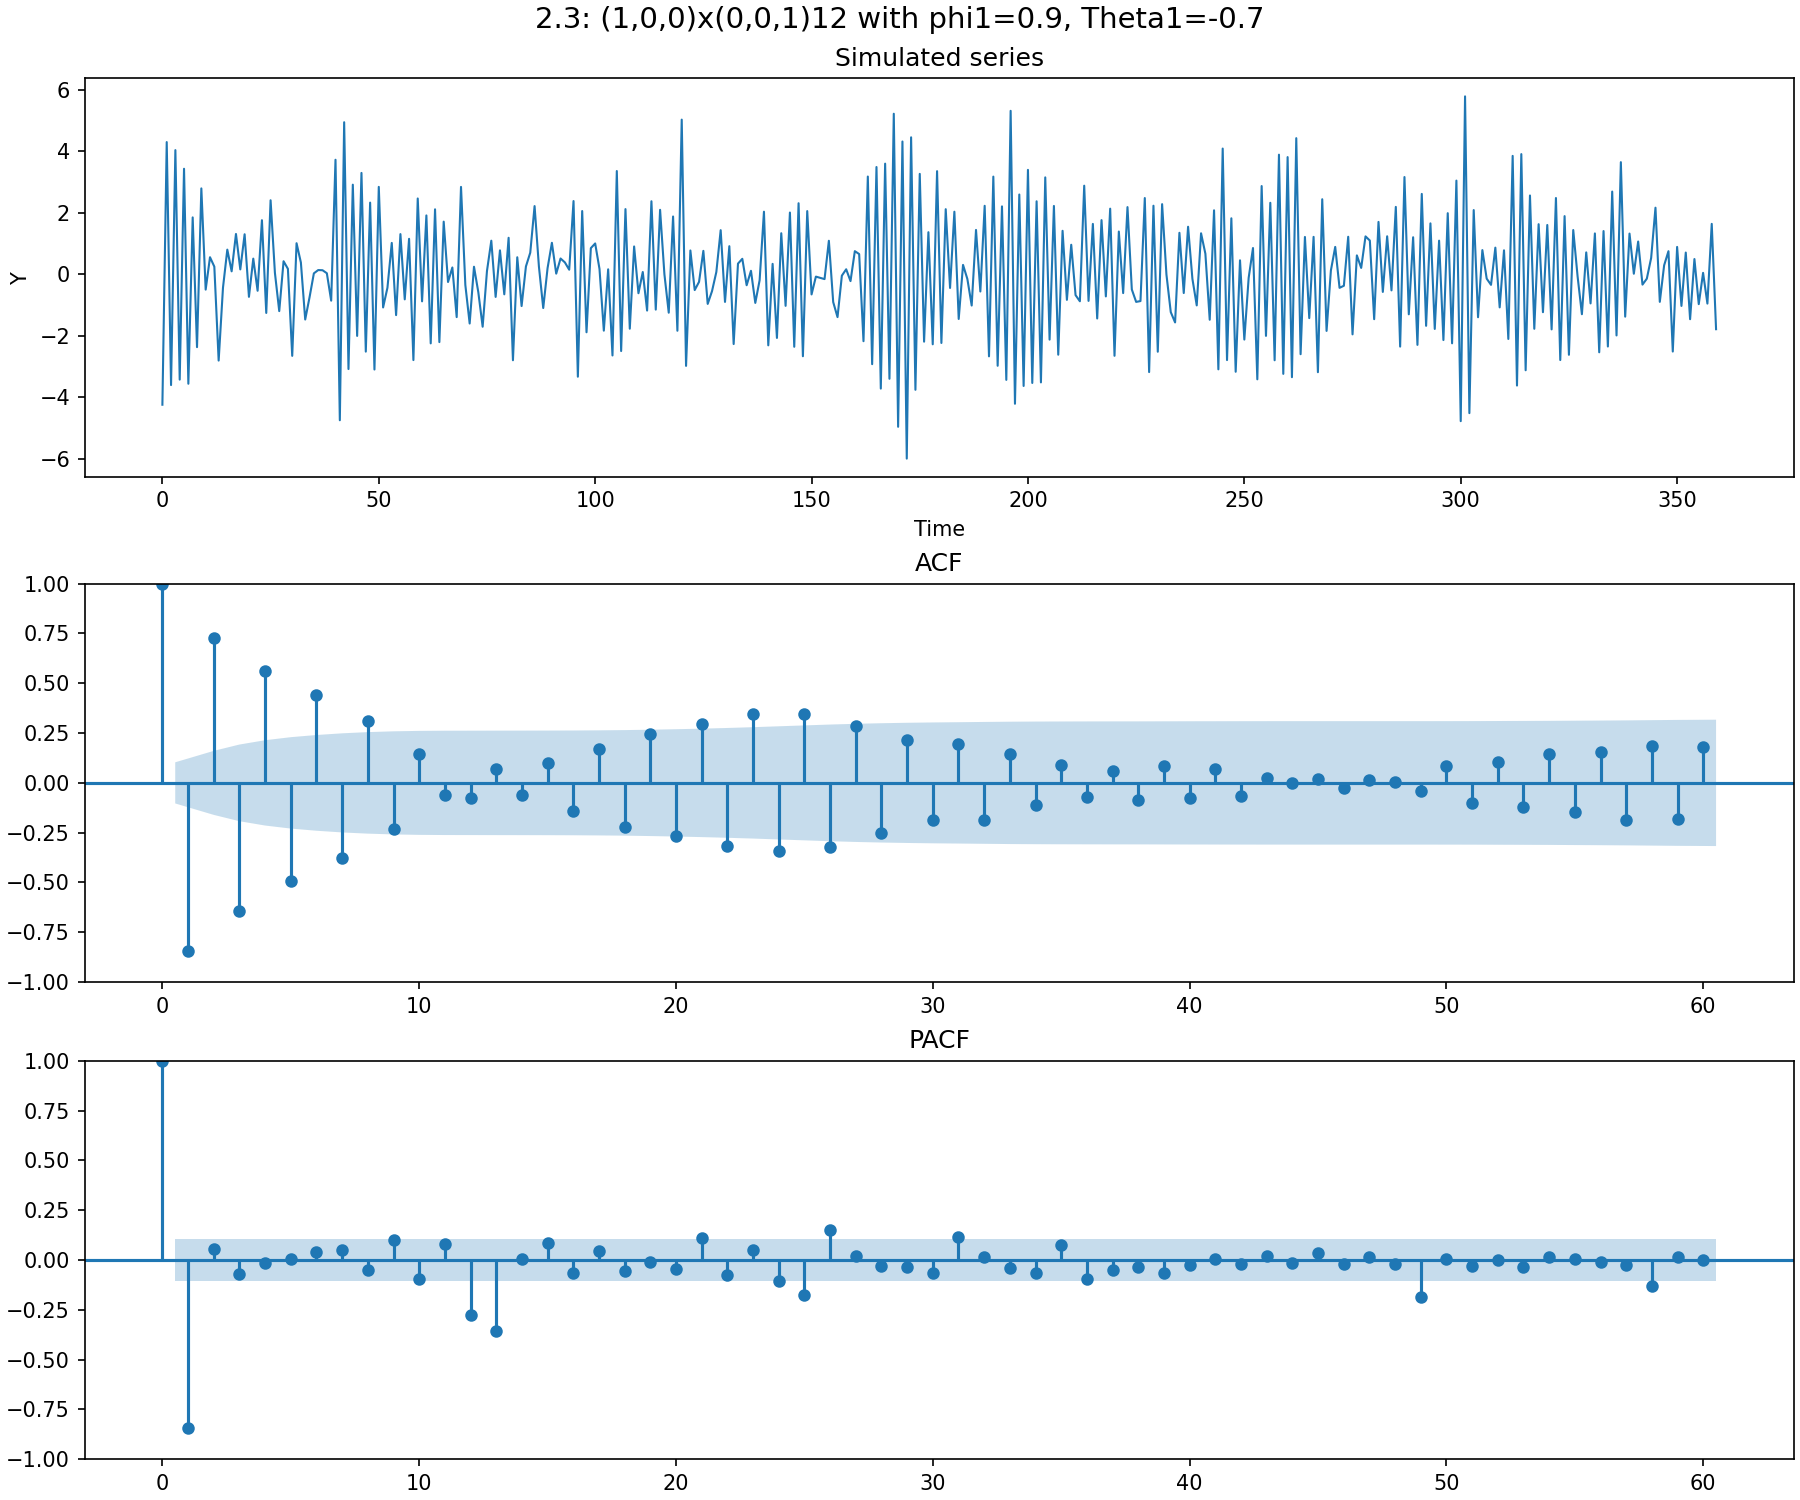

WindowsPath('c:/Users/cheli/OneDrive/Dokumenter/GitHub/TimeSeriesAnalysis_Assignments/Assignment2/task2_outputs/23.png')

In [14]:
# 2.3
run_model(3)

Short comment: Strong non-seasonal persistence (high phi1) is combined with seasonal MA effects, giving oscillatory seasonal structure in the correlations.

2.4: (1,0,0)x(1,0,0)12 with phi1=-0.6, Phi1=-0.8
- Figure: c:\Users\cheli\OneDrive\Dokumenter\GitHub\TimeSeriesAnalysis_Assignments\Assignment2\task2_outputs\24.png
- Both non-seasonal and seasonal AR terms generate structured dependence.
- PACF often has strong spikes at lag 1 and seasonal multiples.


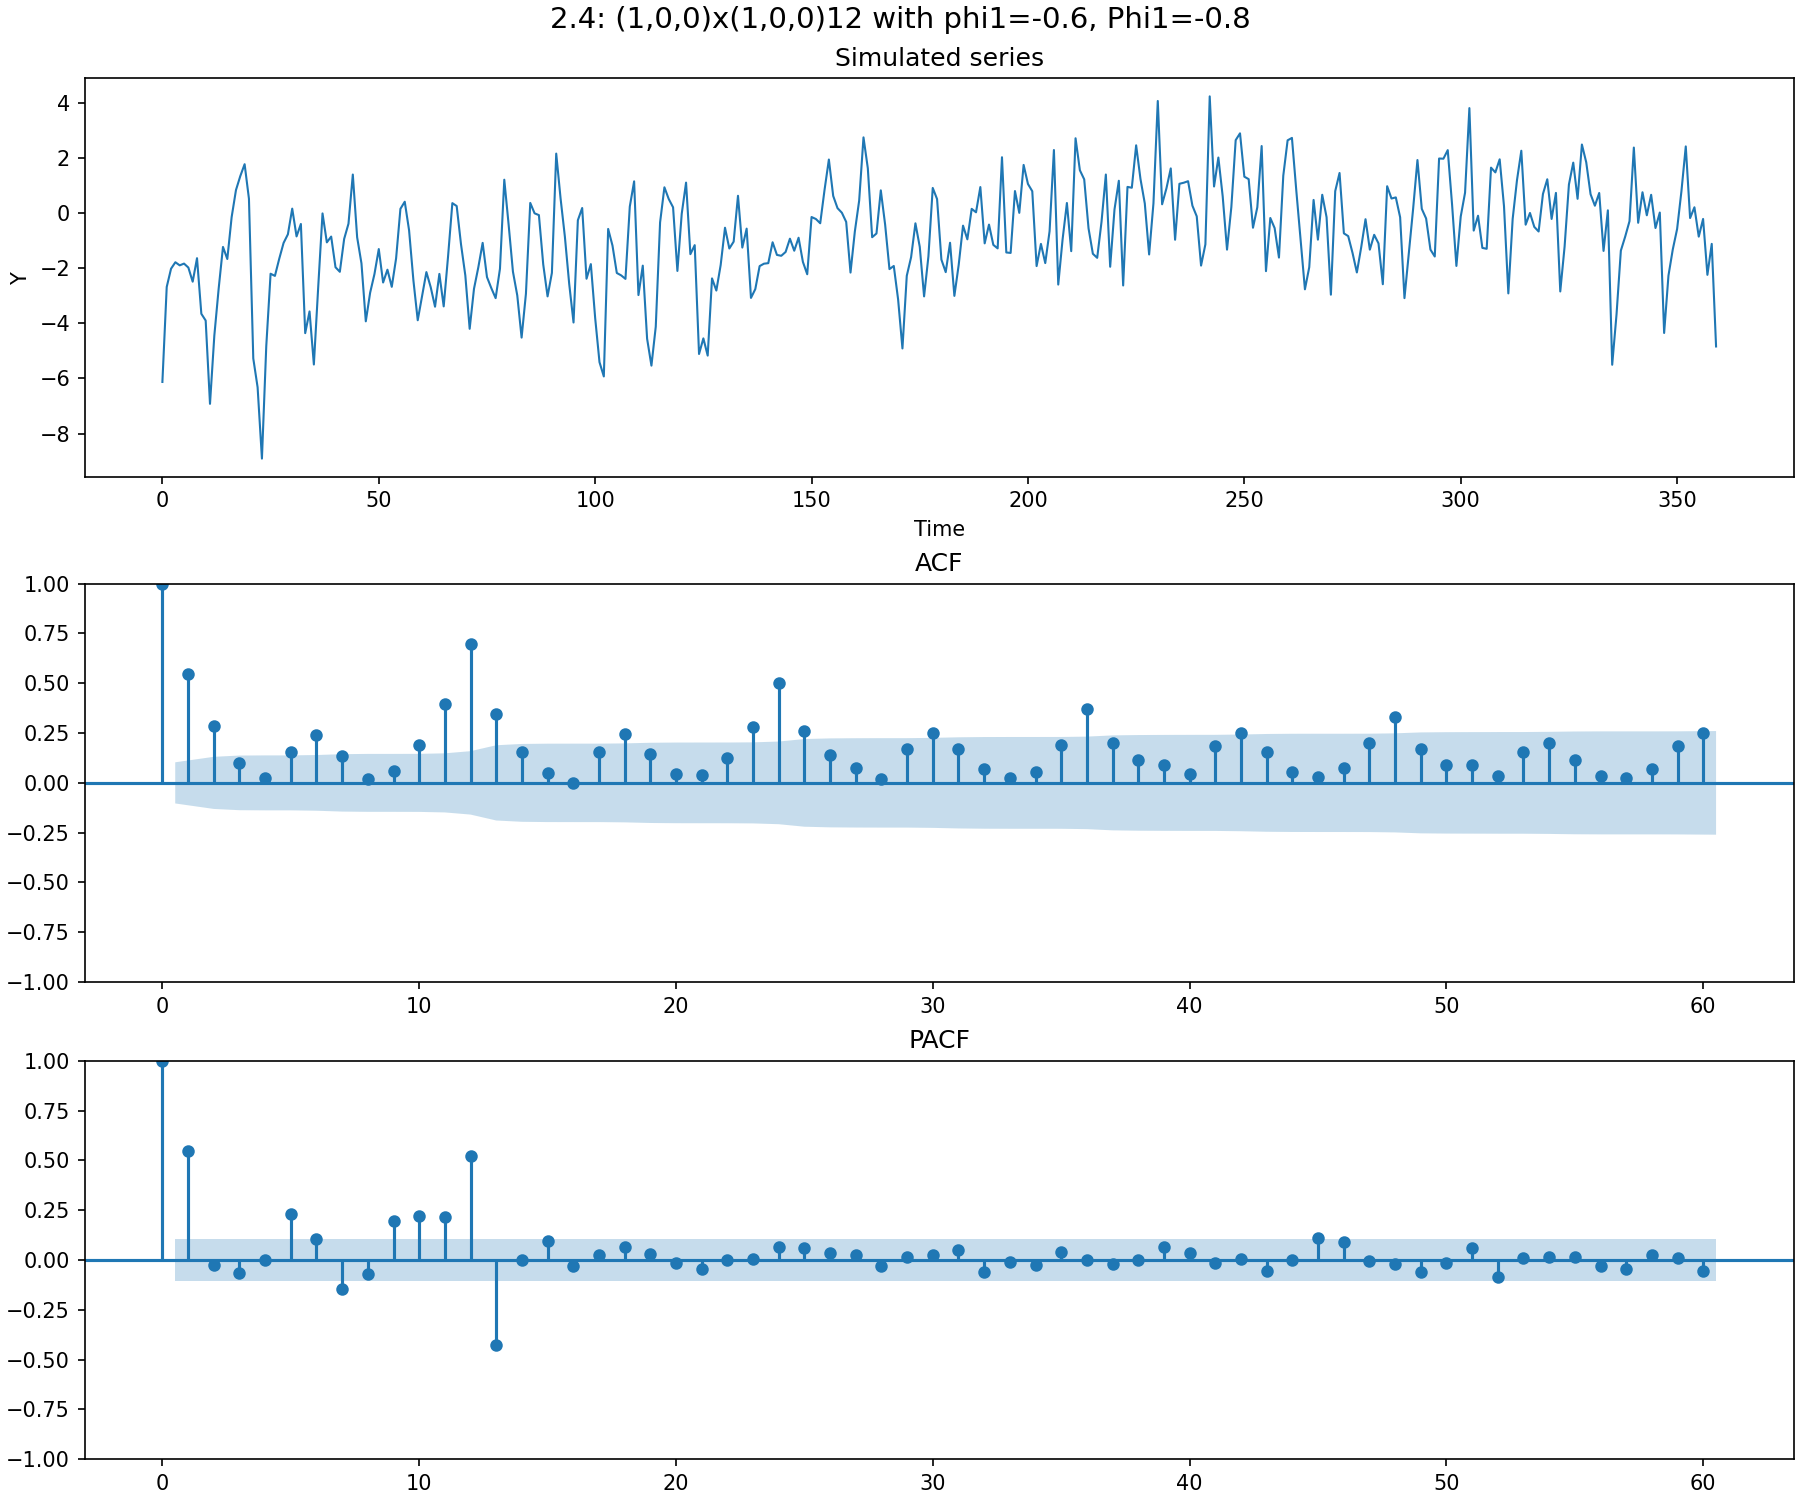

WindowsPath('c:/Users/cheli/OneDrive/Dokumenter/GitHub/TimeSeriesAnalysis_Assignments/Assignment2/task2_outputs/24.png')

In [15]:
# 2.4
run_model(4)

Short comment: With both non-seasonal and seasonal AR terms, dependence is structured at lag 1 and seasonal multiples, visible in both ACF and PACF.

2.5: (0,0,1)x(0,0,1)12 with theta1=0.4, Theta1=-0.8
- Figure: c:\Users\cheli\OneDrive\Dokumenter\GitHub\TimeSeriesAnalysis_Assignments\Assignment2\task2_outputs\25.png
- MA effects are shock-driven and finite-memory in both regular and seasonal lags.
- ACF shows short-run and seasonal signatures; PACF decays more gradually.


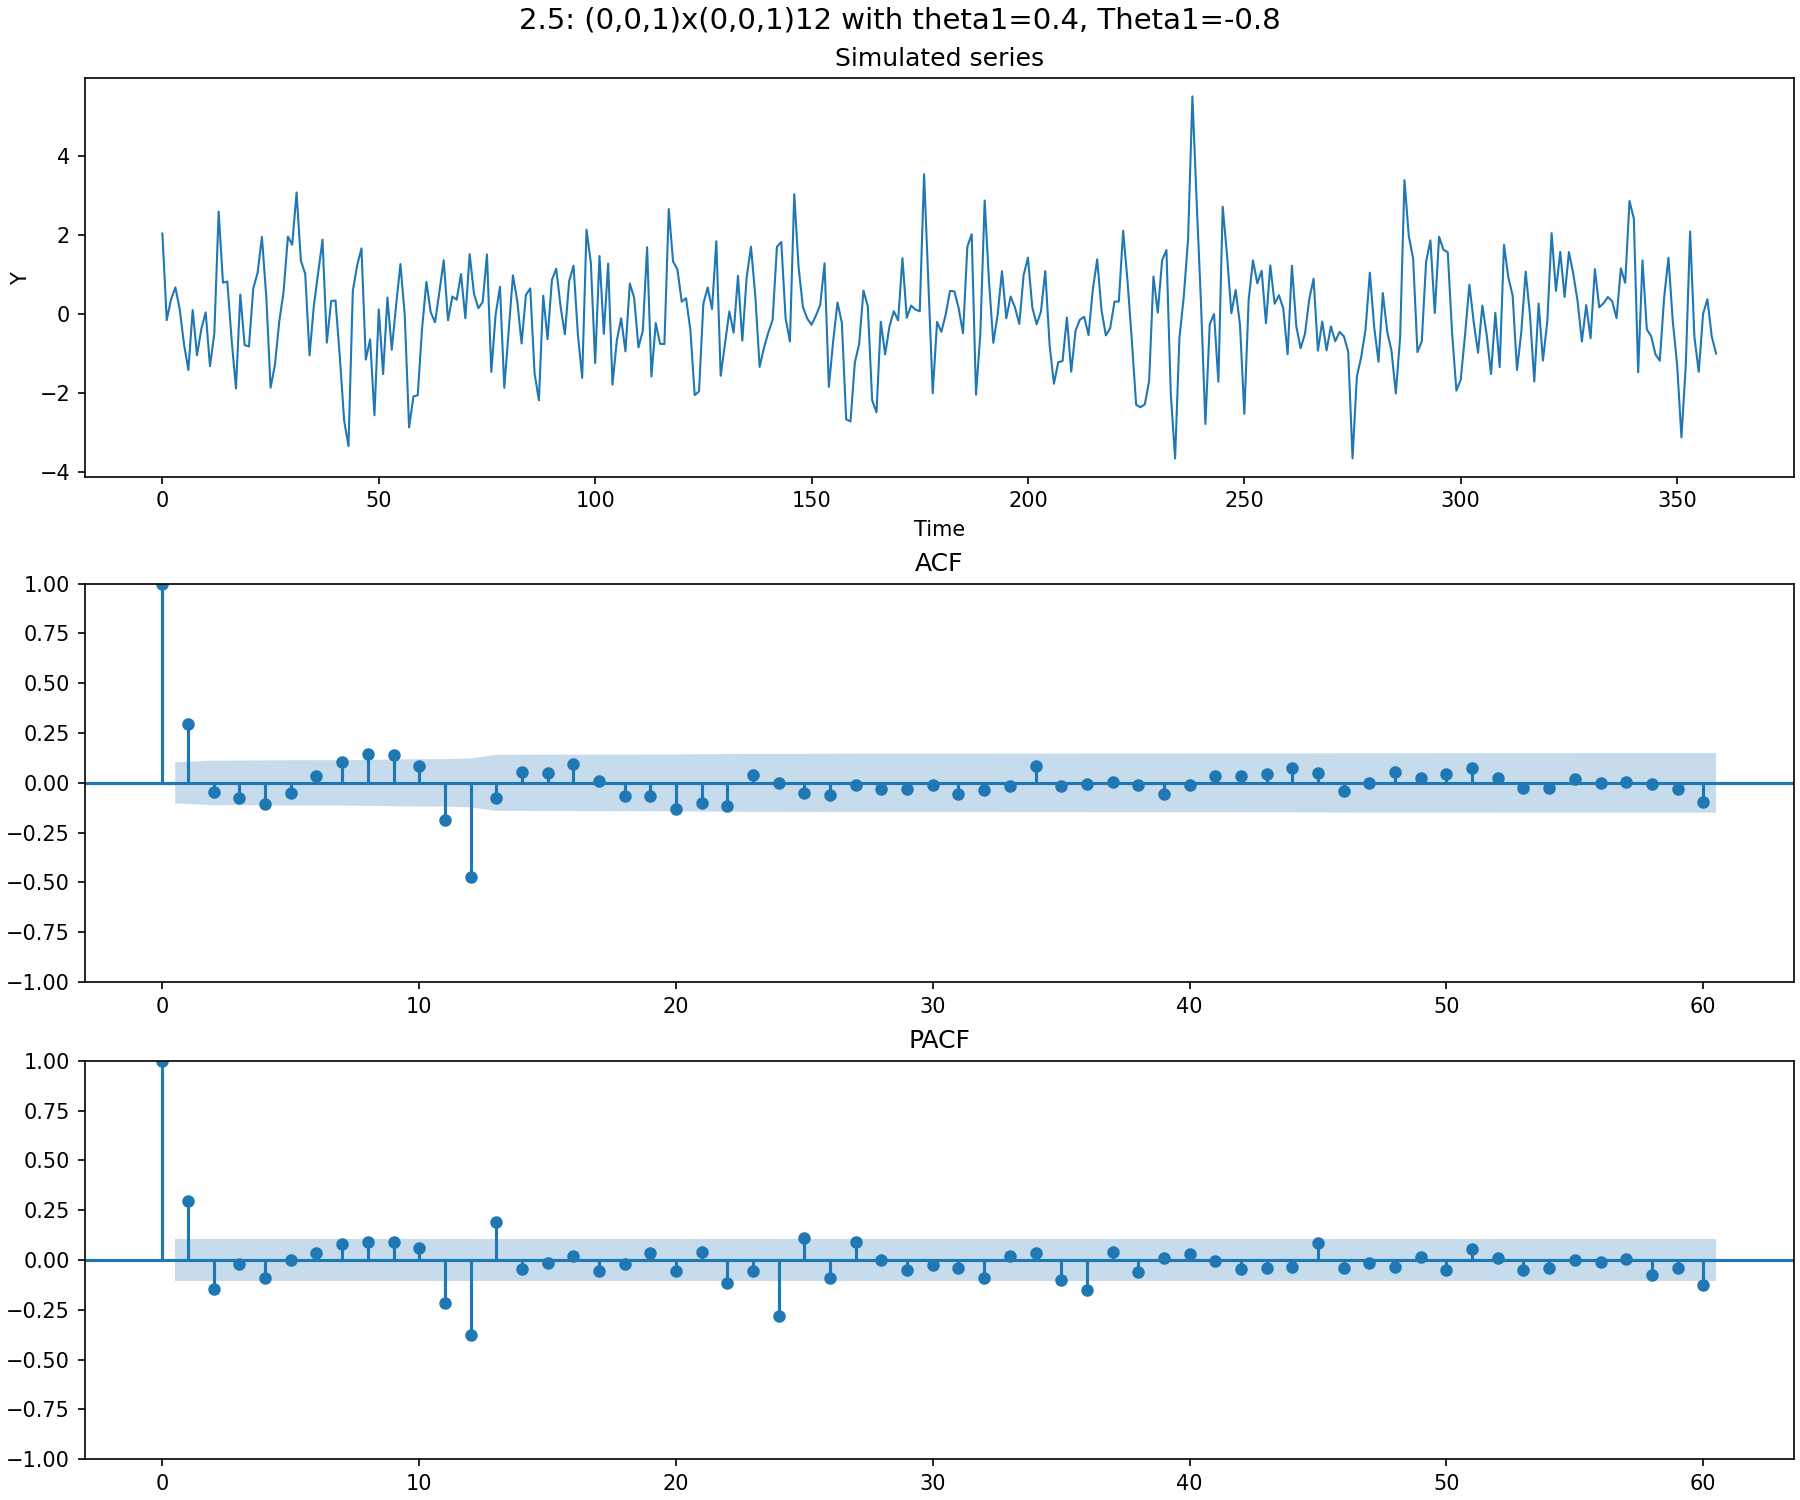

WindowsPath('c:/Users/cheli/OneDrive/Dokumenter/GitHub/TimeSeriesAnalysis_Assignments/Assignment2/task2_outputs/25.png')

In [16]:
# 2.5
run_model(5)

Short comment: This MA + seasonal MA model is mainly shock-driven: ACF has short-lived spikes, including a seasonal spike around lag 12, while PACF is more diffuse.

2.6: (0,0,1)x(1,0,0)12 with theta1=-0.4, Phi1=0.7
- Figure: c:\Users\cheli\OneDrive\Dokumenter\GitHub\TimeSeriesAnalysis_Assignments\Assignment2\task2_outputs\26.png
- Seasonal AR persistence combines with one-step MA shock correction.
- Seasonal pattern appears strongly at lag 12 and multiples in ACF/PACF.


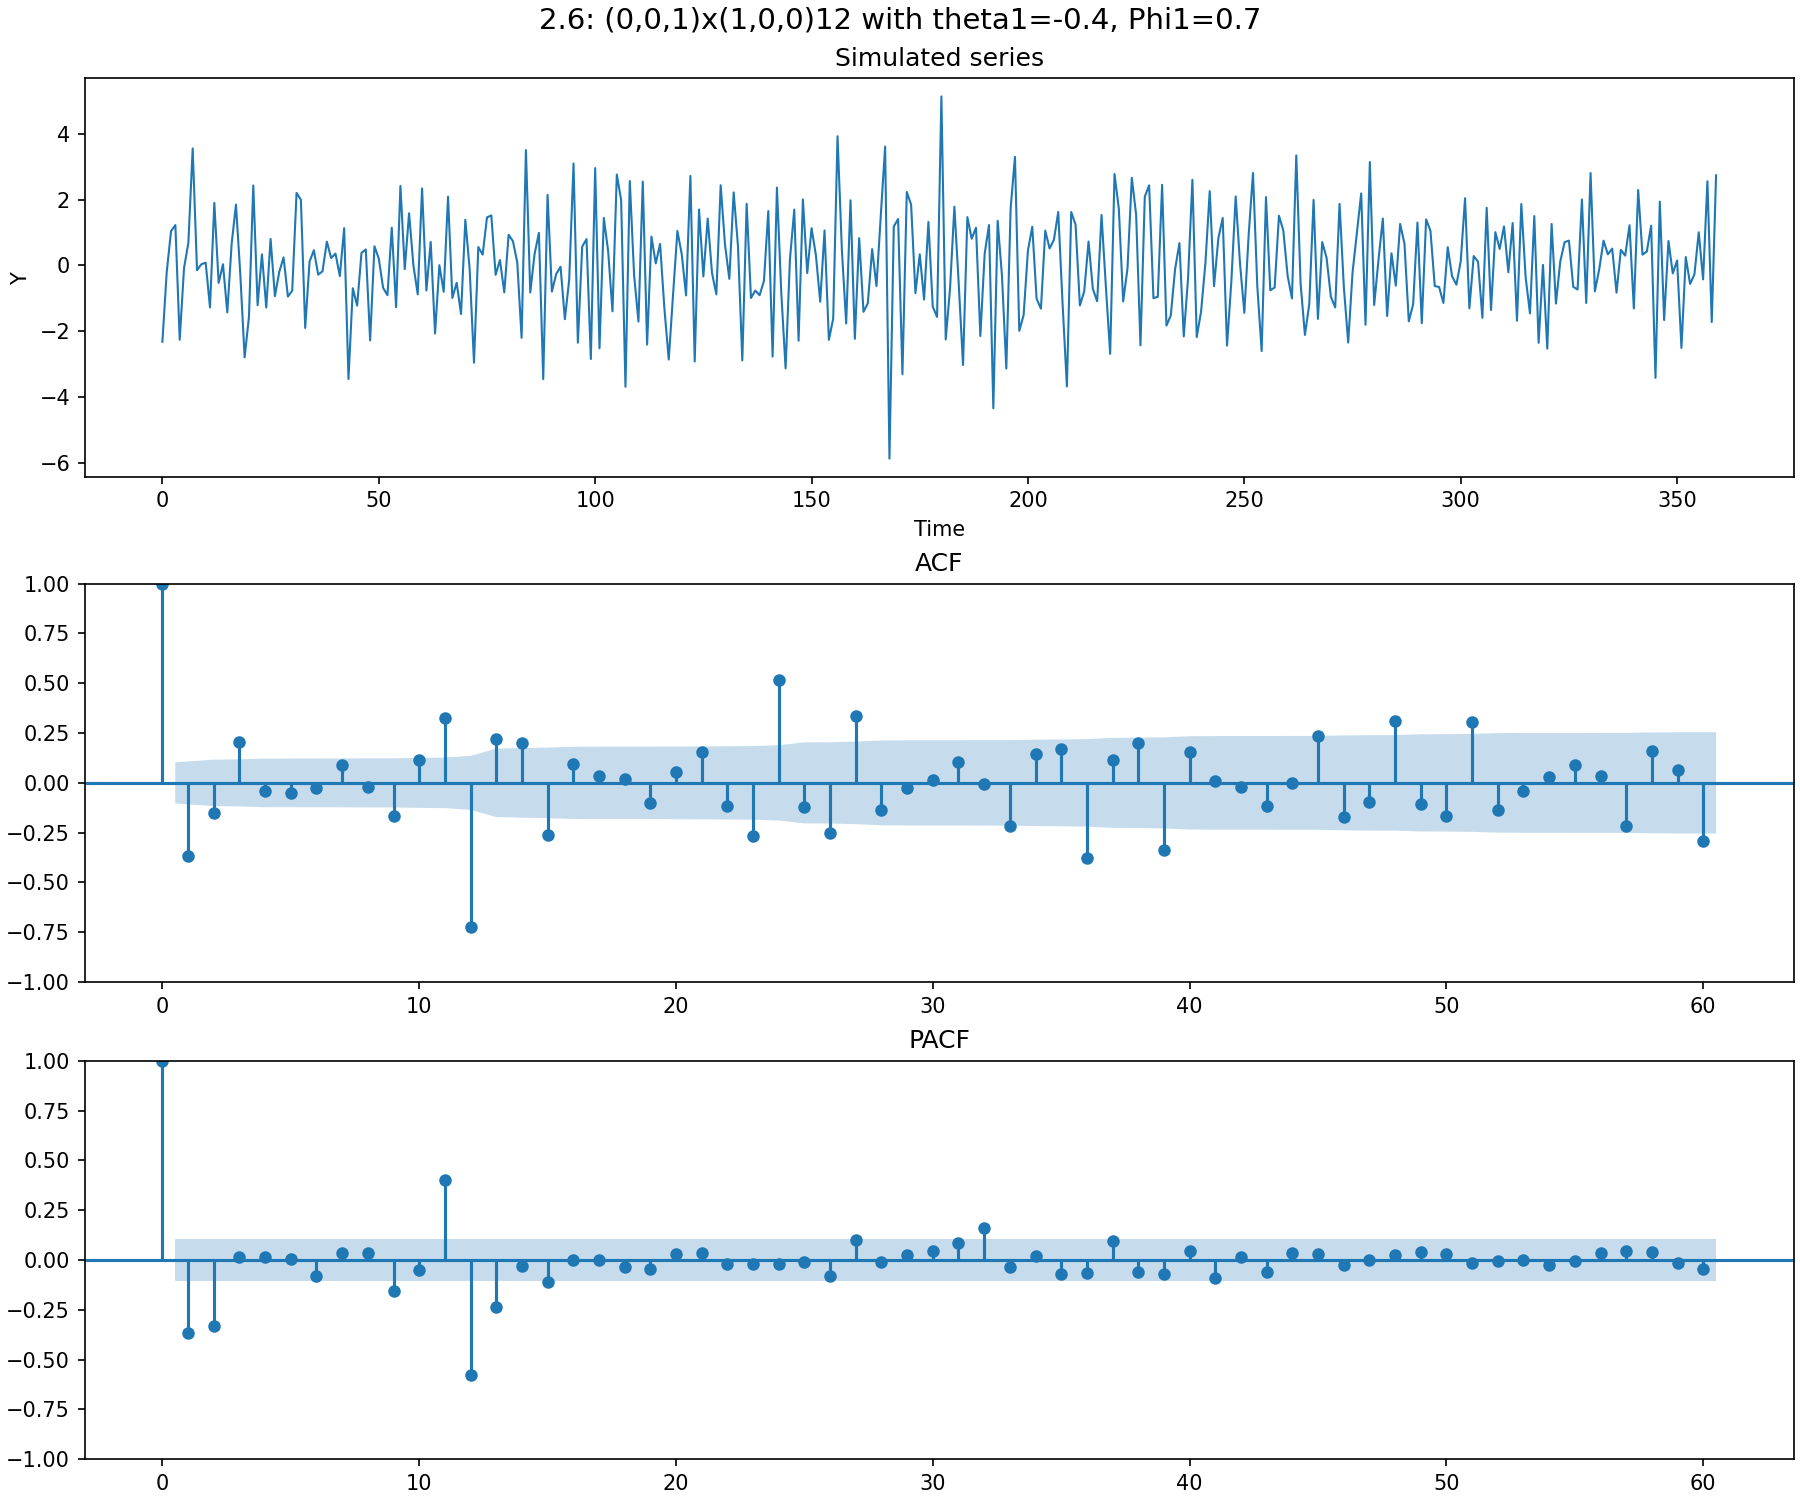

WindowsPath('c:/Users/cheli/OneDrive/Dokumenter/GitHub/TimeSeriesAnalysis_Assignments/Assignment2/task2_outputs/26.png')

In [17]:
# 2.6
run_model(6)

Short comment: Seasonal AR persistence dominates at seasonal lags, while the MA(1) term shapes short-lag behavior, giving a mixed short-run and seasonal signature.

In [18]:
# 2.7
print_summary_27()

2.7 Summary observations
- Seasonal models produce repeated ACF/PACF structure at lags s, 2s, 3s, ... .
- Seasonal AR terms often create persistent seasonal correlations (slow decay at seasonal lags).
- Seasonal MA terms produce more localized seasonal spikes that damp out faster.
- Adding non-seasonal AR/MA changes short-lag behavior while seasonal signatures remain visible.
